In [ ]:
!pip -q install pandas numpy scikit-learn


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
EVENTOS_1499= '/content/drive/MyDrive/TESIS /EVENTOS_PTH_PUBANDING.csv' #Eventos reales
PUNTOS_9957= '/content/drive/MyDrive/TESIS /PTSNODESLIZAMIENTO_99571.csv' # Puntos candidatos no etiquetados

In [ ]:
EVENTOS_1499F= pd.read_csv(EVENTOS_1499)
PUNTOS_9957F= pd.read_csv(PUNTOS_9957)

In [ ]:
print(EVENTOS_1499F.shape, PUNTOS_9957F.shape)


(1499, 13) (9957, 13)


In [ ]:
print(list(EVENTOS_1499F.columns))

['Código_SI', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Geologia_U', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Acum_flujo']


In [ ]:
EVENTOS_1499F.head()

,Código_SI,Dist_vias,Dist_DD,Dist_Falla,Geologia_U,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo
0,40407,5526.839844,6580.950195,0.000000,150,1590,-0.005164,-0.001170,5.09460,-0.905066,0.425272,20.9123,0.69897
1,40441,5526.839844,6580.950195,0.000000,150,1590,-0.005164,-0.001170,5.09460,-0.905066,0.425272,20.9123,0.69897
2,39557,5526.839844,6580.950195,0.000000,150,1590,-0.005164,-0.001170,5.09460,-0.905066,0.425272,20.9123,0.69897
3,40481,424.264008,12888.500000,42.426399,150,2073,-0.000451,-0.001463,6.60012,-0.999846,0.017541,25.4111,1.44716
4,39588,424.264008,12888.500000,42.426399,150,2073,-0.000451,-0.001463,6.60012,-0.999846,0.017541,25.4111,1.44716


In [ ]:
PUNTOS_9957F.head()

,ID_NDES,Dist_vias,Dist_DD,Dist_Falla,Geologia_U,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo
0,0,29027.800781,4021.899902,2490.179932,177,3582,0.000892,0.002463,4.39642,0.108447,0.994102,24.752199,0.477121
1,1,36253.199219,6014.680176,4582.049805,34,3166,0.002942,0.003368,2.72659,0.943460,-0.331486,39.249802,0.000000
2,2,33434.898438,9982.250000,108.167000,179,3029,-0.005408,-0.000920,5.43479,0.935697,0.352804,15.196800,0.698970
3,3,32543.099609,2439.610107,2434.629883,34,2951,-0.001548,0.003036,3.63959,-0.929352,0.369195,18.122700,0.000000
4,4,36585.699219,6747.870117,3050.129883,177,3636,0.001689,0.000429,3.96176,-0.789352,0.613941,35.473999,0.477121


In [ ]:
print(list(PUNTOS_9957F.columns))

['ID_NDES', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Geologia_U', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Acum_flujo']


In [ ]:
ID_EVT = "Código_SI"   # en EVENTOS_1499F
ID_UNL = "ID_NDES"     # en PUNTOS_9957F

In [ ]:
features = ['Dist_vias', 'Dist_DD', 'Dist_Falla', 'Elevacion',
            'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Acum_flujo']



In [ ]:
# Validaciones mínimas

def check_cols(df, required, name):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en {name}: {missing}")

check_cols(EVENTOS_1499F, [ID_EVT] + features, "EVENTOS_1499F")
check_cols(PUNTOS_9957F,  [ID_UNL] + features, "PUNTOS_9957F")

# Asegurar tipo numérico en features (si alguna vino como texto)
for c in features:
    EVENTOS_1499F[c] = pd.to_numeric(EVENTOS_1499F[c], errors="coerce")
    PUNTOS_9957F[c]  = pd.to_numeric(PUNTOS_9957F[c], errors="coerce")

# Eliminar nulos SOLO en features (conservando IDs)

EVENTOS_1499F = EVENTOS_1499F.dropna(subset=features).reset_index(drop=True)
PUNTOS_9957F  = PUNTOS_9957F.dropna(subset=features).reset_index(drop=True)

print("Después de dropna:")
print("EVENTOS_1499F:", EVENTOS_1499F.shape)
print("PUNTOS_9957F :", PUNTOS_9957F.shape)


Después de dropna:
EVENTOS_1499F: (1499, 13)
PUNTOS_9957F : (9957, 13)


In [ ]:
# Construccion de matrices X

X_EVENTOS = EVENTOS_1499F[features].values
X_UNL     = PUNTOS_9957F[features].values

n_pos = X_EVENTOS.shape[0]
n_unl = X_UNL.shape[0]

print("EVENTOS:", EVENTOS_1499F.shape, " | UNL:", PUNTOS_9957F.shape)

EVENTOS: (1499, 13)  | UNL: (9957, 13)


La clase No-Deslizamiento se generó a partir de un conjunto amplio de puntos aleatorios distribuidos en el área de estudio y previamente depurados mediante buffers espaciales alrededor de los eventos inventariados, con el fin de reducir la inclusión de zonas potencialmente afectadas. Sobre este universo candidato se estimó una probabilidad auxiliar de pertenencia a la clase positiva mediante un esquema PU-bagging con cálculo Out-Of-Bag (OOB).

**Out-Of-Bag (OBB):** Hace referencia a que para un punto UNL específico,  solo promedia su probabilidad en aquellas iteraciones donde ese punto NO fue usado como negativo temporal.

In [ ]:
# =====================================================================
# 2) PU-bagging con probabilidad OOB para UNL
#    (evita que el punto se prediga a sí mismo como negativo temporal)
# =====================================================================

# Parámetros PU-bagging (reproducible)
SEED = 42             # Semilla para reproducibilidad
B = 100               # número de repeticiones (baggings)
neg_ratio = 1.0       # En cada repetición va a escoger un grupo de “negativos temporales” del mismo tamaño que los positivos.
n_estimators = 200    # árboles del Random Forest.
n_jobs = -1

rng = np.random.default_rng(SEED)

if int(n_pos * neg_ratio) > n_unl:
    raise ValueError("neg_ratio demasiado alto: se piden más 'negativos' que unlabeled disponibles.")

# Acumuladores OOB para UNL
oob_sum   = np.zeros(n_unl, dtype=np.float64) # Guardará la suma de probabilidades predichas para el punto UNL i, solo cuando esté OOB
oob_count = np.zeros(n_unl, dtype=np.int32)   # Contará cuántas veces el punto UNL i estuvo OOB

# Para control/diagnóstico: probabilidades en eventos (no OOB)
event_probs = np.zeros((B, n_pos), dtype=np.float32)

for b in range(B):

    # 1) muestreo de negativos temporales desde UNL
    idx_neg = rng.choice(n_unl, size=int(n_pos * neg_ratio), replace=False)
    X_neg = X_UNL[idx_neg]

    # 2) train set
    X_train = np.vstack([X_EVENTOS, X_neg])
    y_train = np.hstack([np.ones(n_pos, dtype=int), np.zeros(X_neg.shape[0], dtype=int)])

    # 3) entrenar
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        n_jobs=n_jobs,
        random_state=SEED + b
    )
    clf.fit(X_train, y_train)

    # 4) predicción sobre UNL y actualización SOLO para puntos OOB (no usados como negativos)
    proba_unl = clf.predict_proba(X_UNL)[:, 1]  # prob clase positiva

    mask_oob = np.ones(n_unl, dtype=bool)
    mask_oob[idx_neg] = False  # OOB = no estuvieron como negativos temporales

    oob_sum[mask_oob]   += proba_unl[mask_oob]
    oob_count[mask_oob] += 1

    # (Opcional) control en eventos
    event_probs[b, :] = clf.predict_proba(X_EVENTOS)[:, 1]

# Construir PU_prob_OOB
PU_prob_oob = np.zeros(n_unl, dtype=float)
valid = oob_count > 0
PU_prob_oob[valid] = oob_sum[valid] / oob_count[valid]

# fallback si algún punto nunca quedó OOB (raro con B alto)
if (~valid).any():
    # alternativa conservadora: usar promedio global de las predicciones OOB
    PU_prob_oob[~valid] = np.nanmean(PU_prob_oob[valid])

PUNTOS_9957F["PU_prob_oob"] = PU_prob_oob
EVENTOS_1499F["PU_prob"] = event_probs.mean(axis=0).astype(float)  # solo para comparación/figuras

print("\nResumen PU_prob_oob (UNL):")
print(PUNTOS_9957F["PU_prob_oob"].describe())

print("\nResumen PU_prob (EVENTOS, promedio B):")
print(EVENTOS_1499F["PU_prob"].describe())

# (Opcional) guardar probabilidades UNL
OUT_ALL_PROB = "/content/drive/MyDrive/TESIS/AJUSTE PUBADDING/PU_ALL_9957_con_prob_OOB.csv"
PUNTOS_9957F[[ID_UNL, "PU_prob_oob"]].to_csv(OUT_ALL_PROB, index=False)
print("\nGuardado:", OUT_ALL_PROB)


Resumen PU_prob_oob (UNL):
count    9957.000000
mean        0.275834
std         0.251488
min         0.000774
25%         0.052035
50%         0.188588
75%         0.486768
max         0.943804
Name: PU_prob_oob, dtype: float64

Resumen PU_prob (EVENTOS, promedio B):
count    1499.000000
mean        0.902780
std         0.061013
min         0.632200
25%         0.871975
50%         0.912800
75%         0.945850
max         1.000000
Name: PU_prob, dtype: float64

Guardado: /content/drive/MyDrive/TESIS/AJUSTE PUBADDING/PU_ALL_9957_con_prob_OOB.csv


In [ ]:
# ===============================================================
# 3) Selección de NO_DESL por Muestreo Ponderado (Probabilístico)
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def seleccionar_no_desl_ponderado(df_unl, col_prob, n_select, seed, exponente=2, p_corte=85):

    """
    Selecciona NO_DESL con muestreo ponderado inverso + corte superior por percentil.
    - Pesos: (1 - prob)^exponente  -> favorece prob baja, permite cola intermedia.
    - Corte superior p_corte: elimina candidatos con probabilidad muy alta (más ambiguos).
    Devuelve:
      muestra (df), info (dict con controles)
    """

    df = df_unl.copy()

    # Limpieza robusta de probabilidad
    df[col_prob] = df[col_prob].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col_prob])


    if len(df) < n_select:
        raise ValueError(f"No hay suficientes candidatos válidos: {len(df)} < {n_select}")


    # Corte superior por percentil (control de ambigüedad)
    thr = np.percentile(df[col_prob].values, p_corte)
    df = df[df[col_prob] <= thr].copy()


    if len(df) < n_select:
        raise ValueError(
            f"Tras aplicar corte p{p_corte} (thr={thr:.6f}) no hay suficientes candidatos: "
            f"{len(df)} < {n_select}. Suba p_corte o reduzca n_select."

        )


    # Pesos inversos a la probabilidad (más prob -> menos peso)
    pesos = (1 - df[col_prob]) ** exponente
    pesos = pesos.clip(lower=0)  # seguridad numérica
    suma_pesos = pesos.sum()

    if suma_pesos <= 0:
        raise ValueError("La suma de pesos es 0. Revise col_prob o el exponente.")

    pesos_norm = pesos / suma_pesos


    # Muestreo ponderado
    muestra = df.sample(n=n_select, weights=pesos_norm, random_state=seed).copy()


    # Info de control para trazabilidad
    info = {
        "metodo": "PONDERADO_CON_CORTE",
        "col_prob": col_prob,
        "exponente": float(exponente),
        "p_corte": int(p_corte),
        "thr_corte": float(thr),
        "n_candidatos_post_corte": int(len(df)),
        "prob_media": float(muestra[col_prob].mean()),
        "prob_min": float(muestra[col_prob].min()),
        "prob_max": float(muestra[col_prob].max())
    }

    return muestra, info





In [ ]:
# =======================================
# 4) Aplicación (dataset balanceado)
# =======================================

NO_DESL_PONDERADO, info_p = seleccionar_no_desl_ponderado(
    PUNTOS_9957F, "PU_prob_oob", n_pos, SEED, exponente=2, p_corte=85
)

print("\nDataset Generado con Muestreo Ponderado + Corte superior")
print(info_p)
print(f"Rango de probabilidades en negativos seleccionados: {info_p['prob_min']:.4f} a {info_p['prob_max']:.4f}")

# Etiquetas
NO_DESL_PONDERADO = NO_DESL_PONDERADO.copy()
NO_DESL_PONDERADO["Clase"] = 0

EVENTOS = EVENTOS_1499F.copy()
EVENTOS["Clase"] = 1

# Trazabilidad
NO_DESL_PONDERADO["METODO_NEG"] = f"PONDERADO_exp{int(info_p['exponente'])}_pc{info_p['p_corte']}"
NO_DESL_PONDERADO["SEED"] = SEED

EVENTOS["METODO_NEG"] = "EVENTO_REAL"
EVENTOS["SEED"] = SEED

DATASET_FINAL_P = pd.concat([EVENTOS, NO_DESL_PONDERADO], ignore_index=True)

print("\nConteo clases:", DATASET_FINAL_P["Clase"].value_counts().to_dict())



Dataset Generado con Muestreo Ponderado + Corte superior
{'metodo': 'PONDERADO_CON_CORTE', 'col_prob': 'PU_prob_oob', 'exponente': 2.0, 'p_corte': 85, 'thr_corte': 0.6095313668466972, 'n_candidatos_post_corte': 8463, 'prob_media': 0.128795163132107, 'prob_min': 0.0009770114942528737, 'prob_max': 0.6095180722891568}
Rango de probabilidades en negativos seleccionados: 0.0010 a 0.6095

Conteo clases: {1: 1499, 0: 1499}


In [ ]:
# =======================================
# 6) Exportar CSV para Join en ArcGIS + dataset final (opcional)
# =======================================
# Ajuste rutas según su Drive
OUT_NO_JOIN = f"/content/drive/MyDrive/TESIS/AJUSTE PUBADDING/NO_DESL_1499_para_join_{NO_DESL_PONDERADO['METODO_NEG'].iloc[0]}.csv"
OUT_DATASET = f"/content/drive/MyDrive/TESIS/AJUSTE PUBADDING/DATASET_TRAIN_BALANCEADO_1499_1499_{NO_DESL_PONDERADO['METODO_NEG'].iloc[0]}.csv"

# Para join, normalmente basta ID + prob + trazabilidad
NO_DESL_PONDERADO[[ID_UNL, "PU_prob_oob", "METODO_NEG", "SEED"]].to_csv(OUT_NO_JOIN, index=False)
DATASET_FINAL_P.to_csv(OUT_DATASET, index=False)

print("\nGuardado NO_DESL join:", OUT_NO_JOIN)
print("Guardado DATASET final:", OUT_DATASET)
print(f"JOIN en ArcGIS: capa puntos ({ID_UNL}) <-> CSV ({ID_UNL})")


Guardado NO_DESL join: /content/drive/MyDrive/TESIS/AJUSTE PUBADDING/NO_DESL_1499_para_join_PONDERADO_exp2_pc85.csv
Guardado DATASET final: /content/drive/MyDrive/TESIS/AJUSTE PUBADDING/DATASET_TRAIN_BALANCEADO_1499_1499_PONDERADO_exp2_pc85.csv
JOIN en ArcGIS: capa puntos (ID_NDES) <-> CSV (ID_NDES)


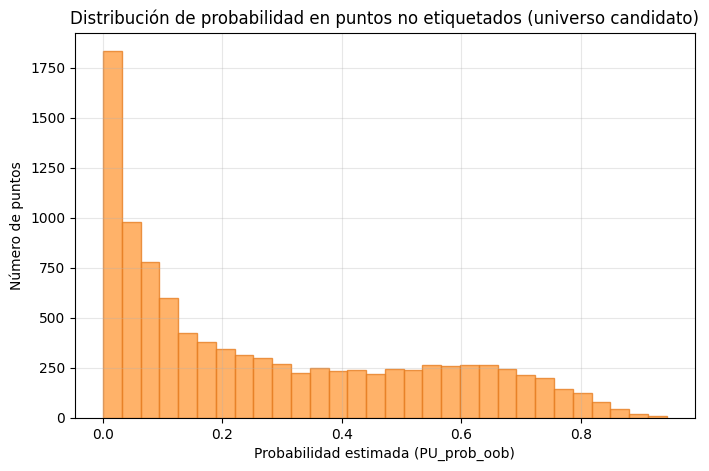

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# Distribución en universo candidato (UNL)
# ================================
plt.figure(figsize=(8,5))

plt.hist(
    PUNTOS_9957F["PU_prob_oob"].replace([np.inf, -np.inf], np.nan).dropna(),
    bins=30,
    color='#FF9F43',
    edgecolor='#E67E22',
    alpha=0.8
)

plt.xlabel("Probabilidad estimada (PU_prob_oob)")
plt.ylabel("Número de puntos")
plt.title("Distribución de probabilidad en puntos no etiquetados (universo candidato)")
plt.grid(alpha=0.3)
plt.show()



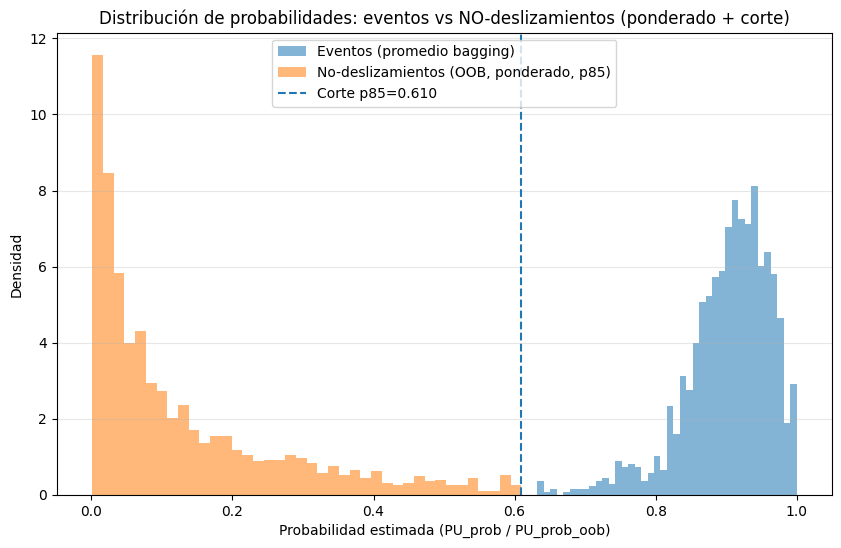

In [ ]:
# =======================================
# Gráfica (densidad comparable)
# =======================================
plt.figure(figsize=(10, 6))

plt.hist(
    EVENTOS_1499F["PU_prob"],
    bins=40, alpha=0.55, density=True,
    label="Eventos (promedio bagging)"
)

plt.hist(
    NO_DESL_PONDERADO["PU_prob_oob"],
    bins=40, alpha=0.55, density=True,
    label=f"No-deslizamientos (OOB, ponderado, p{info_p['p_corte']})"
)

plt.axvline(info_p["thr_corte"], linestyle="--", linewidth=1.5, label=f"Corte p{info_p['p_corte']}={info_p['thr_corte']:.3f}")

plt.xlabel("Probabilidad estimada (PU_prob / PU_prob_oob)")
plt.ylabel("Densidad")
plt.title("Distribución de probabilidades: eventos vs NO-deslizamientos (ponderado + corte)")
plt.legend(loc="upper center")
plt.grid(axis="y", alpha=0.3)
plt.show()




/tmp/ipython-input-3067509256.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


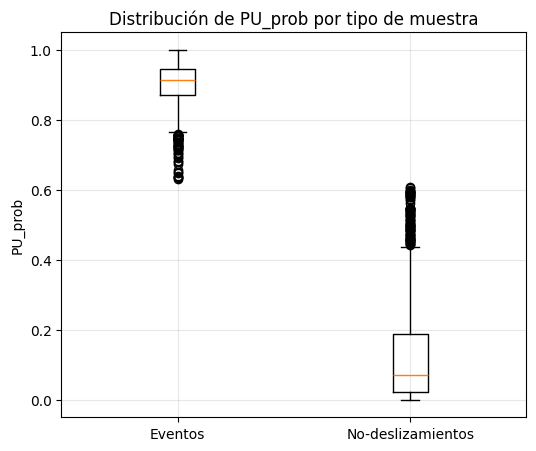

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        EVENTOS_1499F["PU_prob"].replace([np.inf, -np.inf], np.nan).dropna(),
        NO_DESL_PONDERADO["PU_prob_oob"].replace([np.inf, -np.inf], np.nan).dropna()
    ],
    labels=["Eventos", "No-deslizamientos"],
    showfliers=True
)

plt.ylabel("PU_prob")
plt.title("Distribución de PU_prob por tipo de muestra")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# 1. CORREGIR NOTEBOOK PARA GITHUB SIN BORRAR SALIDAS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import nbformat
from pathlib import Path
import shutil

# Ruta del notebook original en Drive
ruta_original = Path("/content/drive/MyDrive/Colab Notebooks/GENERACIONPUNTOS_NO DESLIZAMIENTOSV2.ipynb")

# Crear una copia corregida para GitHub
ruta_corregida = ruta_original.with_name(ruta_original.stem + "_GH.ipynb")

# Crear copia de seguridad adicional
ruta_backup = ruta_original.with_name(ruta_original.stem + "_BACKUP.ipynb")
shutil.copy(ruta_original, ruta_backup)

# Leer notebook
nb = nbformat.read(ruta_original, as_version=4)

# Eliminar SOLO el metadato problemático
# Esto NO borra salidas, gráficos, tablas ni resultados de celdas
nb.metadata.pop("widgets", None)

# Guardar versión corregida
nbformat.write(nb, ruta_corregida)

print("Notebook corregido correctamente.")
print("Archivo original:", ruta_original)
print("Copia de seguridad:", ruta_backup)
print("Archivo para subir a GitHub:", ruta_corregida)